In [1]:
library(Seurat)
library(scop)
library(Signac)
library(ggplot2)
set.seed(4180)
setwd("/")
#########color
cols <- c("#444576", "#4682B4",
 "#AEDEEE","#FFA500",
 "#FFD790","#C65762","#FBDFDE",
 "#F6EFCF","#BCB99F")
pal <- colorRampPalette(cols)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Registered S3 method overwritten by 'scop':
  method             from  
  FoldChange.default Seurat

          ⬢          .        ⬡             ⬢     .
                     _____ _________  ____
                    / ___// ___/ __ ./ __ .
                   (__  )/ /__/ /_/ / /_/ /
                  /____/ .___/.____/ .___/
                                  /_/
      ⬢               .      ⬡        .          ⬢

------------------------------------------------------------
Version: 0.8.7 (2026-03-31 update)
Website: https://mengxu98.github.io/scop/

Python environment initialization is disabled
To enable it, set: options(scop_env_init = TRUE)

The message can be suppressed by: 
  suppressPackageStartupMessages(library(scop))
  or options(log_message.verbose = FALSE)
------------------------------------------

In [10]:
vCM <- readRDS("data/vCM.Rds")
DefaultAssay(vCM) <- "RNA"

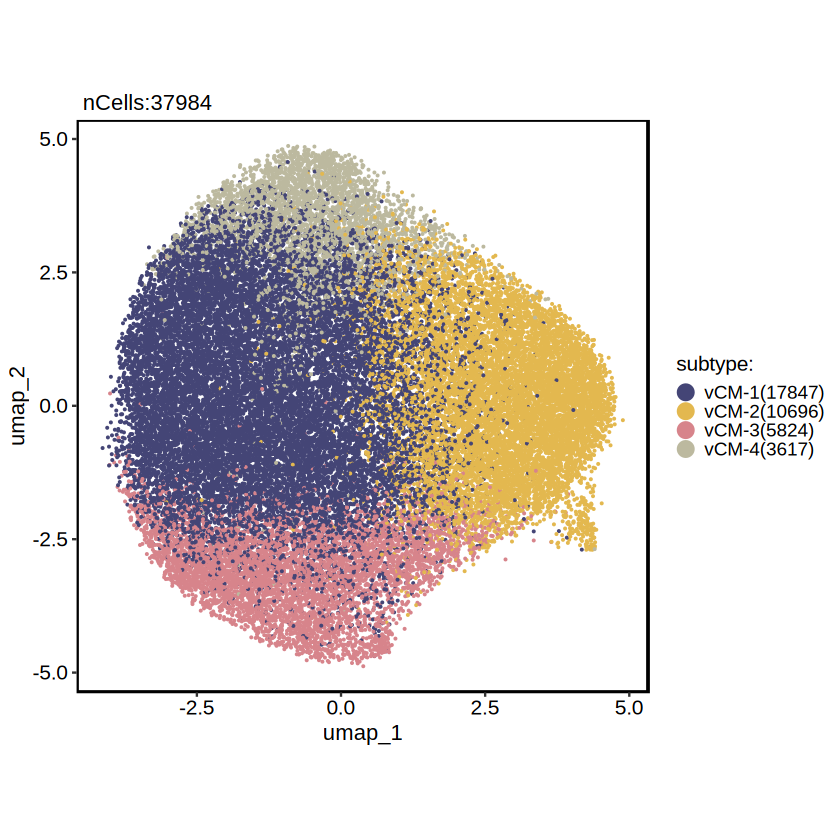

In [3]:
# fig2a
p <- CellDimPlot(
 srt = vCM, group.by = "subtype",
 legend.position = "right", label_repel = T,
 label_point_size = 0.1, reduction = "umap",
 label = F, label_insitu = T,
 theme_use = "theme_scop",
 palcolor = pal(4), raster = F,
 label.fg = "black", label.bg = "grey95",
 label.bg.r = 0
)
ggsave(
 plot = p, filename = "fig2a_vCMumap.pdf", path = "plot/figure2/",
 create.dir = TRUE, width = 4, height = 4
)
p

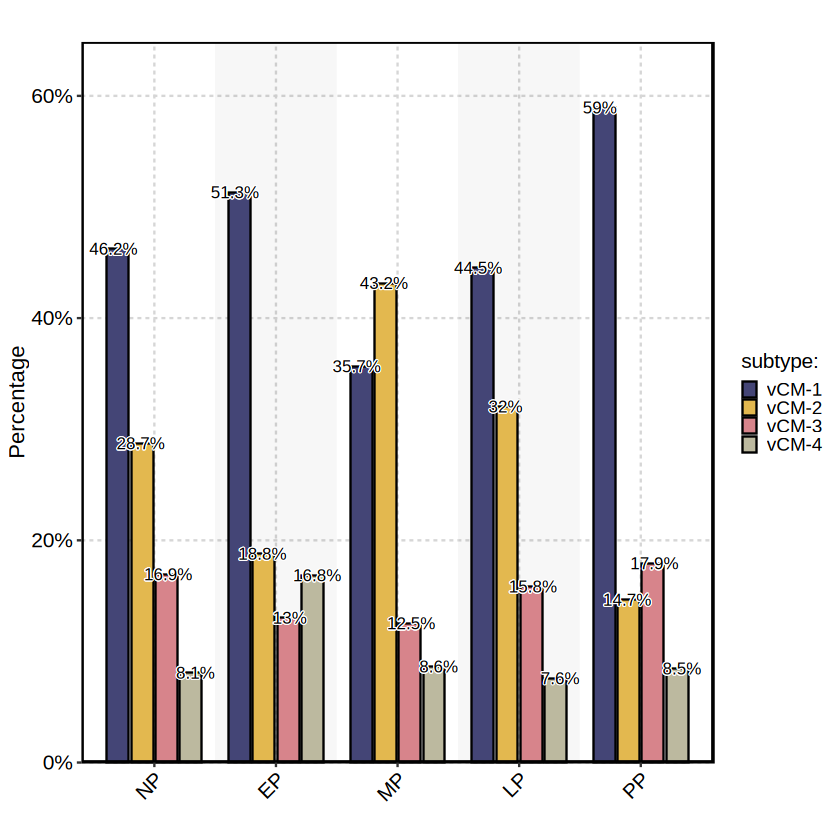

In [4]:
#fig2b
p <- CellStatPlot(vCM, stat.by = "subtype", group.by = "group",
 label = T,palcolor = pal(4),position ="dodge",
 plot_type = "bar",xlab = '',ylab = 'Percentage')
p 
ggsave(plot = p,filename = "fig2b_vCMstat.pdf",path = "plot/figure2/",
 create.dir = TRUE,width = 6,height = 3)

In [5]:
# fig2c
library(ComplexHeatmap)
library(dplyr)
DefaultAssay(vCM) <- "RNA"
vCM <- RunDEtest(vCM,
 group.by = "subtype", fc.threshold = 1.2, cores = 4,
 assay = "RNA", only.pos = T, min.pct = 0.25
)
AllMarkers <- filter(
 vCM@tools$DEtest_subtype$AllMarkers_wilcox,
 p_val_adj < 0.05,
 test_group_number == 1
)
AllMarkers <- AllMarkers %>%
 filter(p_val_adj < 0.05) %>%
 group_by(group1) %>%
 arrange(desc(avg_log2FC)) %>%
 slice_head(n = 50)
AllMarkers$label <- rownames(AllMarkers)
result <- AllMarkers %>%
 filter(p_val_adj < 0.05) %>%
 group_by(group1) %>%
 arrange(desc(avg_log2FC)) %>%
 slice_head(n = 5)
ave.dt <- scale(
 t(as.matrix(AverageExpression(vCM[AllMarkers$gene, ],
 group.by = "subtype", assays = "RNA", layer = "data"
)$RNA)))
ave.dt <- ave.dt[, AllMarkers$gene]
ha <- HeatmapAnnotation(foo = anno_mark(
 at = as.numeric(result$label),
 labels = result$gene,
 labels_gp = gpar(fontsize = 10, rot = 45, fontface = "italic")
))
pdf("plot/figure2/fig2c_vCMsubtype_markers.pdf", width = 6, height = 3) # save as pdf file
draw(Heatmap(ave.dt,
 cluster_columns = F,
 cluster_rows = F, col = c("grey80", "white", "#444576"),
 show_column_names = F,
 heatmap_legend_param = list(
 title = "Expression", at = c(-2, 0, 2),
 labels = c("Min", "", "Max")
 ),
 top_annotation = ha, row_names_side = "left",
 width = unit(10, "cm"), height = unit(4, "cm")
))
dev.off()

Loading required package: grid

ComplexHeatmap version 2.26.1
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




ℹ [2026-05-07 23:24:29] Data type is log-normalized

ℹ [2026-05-07 23:24:29] Start differential expression test

ℹ [2026-05-07 23:24:29] Find all markers(wilcox) among [1] 4 groups...

ℹ [2026-05-07 23:24:29] Using 4 cores

⠙ [2026-05-07 23:24:29] Running for vCM-1... [1/4] ■■          25% | ETA: 16s

⠹ [2026-05-07 23:24:29] Running for vCM-2... [2/4] ■■■■■       50% | ETA: 11s

⠸ [2026-05-07 23:24:29] Running for vCM-3... [3/4] ■■■■■■■     75% | ETA:  6s

✔ [2026-05-07 23:24:29] Completed 4 tasks in 23.2s



ℹ [2026-05-07 23:24:29] Building results

✔ [2026-05-07 23:24:52] Differential expression test completed

As of Seurat v5, we recommend using AggregateExpression to perform pseudo-bulk analysis.
This message is displayed once per session.


agg_record_5832d3c78b8d7 
                       2

In [6]:
#fig2d
DefaultAssay(vCM) <- "RNA"
vCM <- RunDEtest(vCM, group.by = "subtype", only.pos = FALSE, fc.threshold = 1)
vCM <- RunGSEA(vCM,
group.by = "subtype", DE_threshold = "p_val_adj < 0.05",
scoreType = "std", db = "GO_BP", species = "Mus_musculus"
)

ℹ [2026-05-07 23:25:13] Data type is log-normalized

ℹ [2026-05-07 23:25:13] Start differential expression test

ℹ [2026-05-07 23:25:13] Find all markers(wilcox) among [1] 4 groups...

ℹ [2026-05-07 23:25:13] Using 1 core

⠙ [2026-05-07 23:25:13] Running for vCM-1 [1/4] ■■          25% | ETA:  1m

⠹ [2026-05-07 23:25:13] Running for vCM-2 [2/4] ■■■■■       50% | ETA: 37s

⠸ [2026-05-07 23:25:13] Running for vCM-3 [3/4] ■■■■■■■     75% | ETA: 17s

✔ [2026-05-07 23:25:13] Completed 4 tasks in 1m 6.5s



ℹ [2026-05-07 23:25:13] Building results

✔ [2026-05-07 23:26:20] Differential expression test completed

ℹ [2026-05-07 23:26:20] Start GSEA analysis

ℹ [2026-05-07 23:26:20] Species: "Mus_musculus"

ℹ [2026-05-07 23:26:20] Loading cached: GO_BP version: 3.22.0 nterm:15169 created: 2026-04-11 23:52:29

ℹ [2026-05-07 23:26:21] Using 1 core



⠙ [2026-05-07 23:26:21] Running for 1 [1/4] ■■          25% | ETA:  4m

⠹ [2026-05-07 23:26:21] Running for 2 [2/4] ■■■■■       50% | ETA:  3m

⠸ [20

In [7]:
writexl::write_xlsx(data.frame(vCM@tools$GSEA_subtype_wilcox),"plot/figure2/fig1d_vCM_gsea.xlsx")

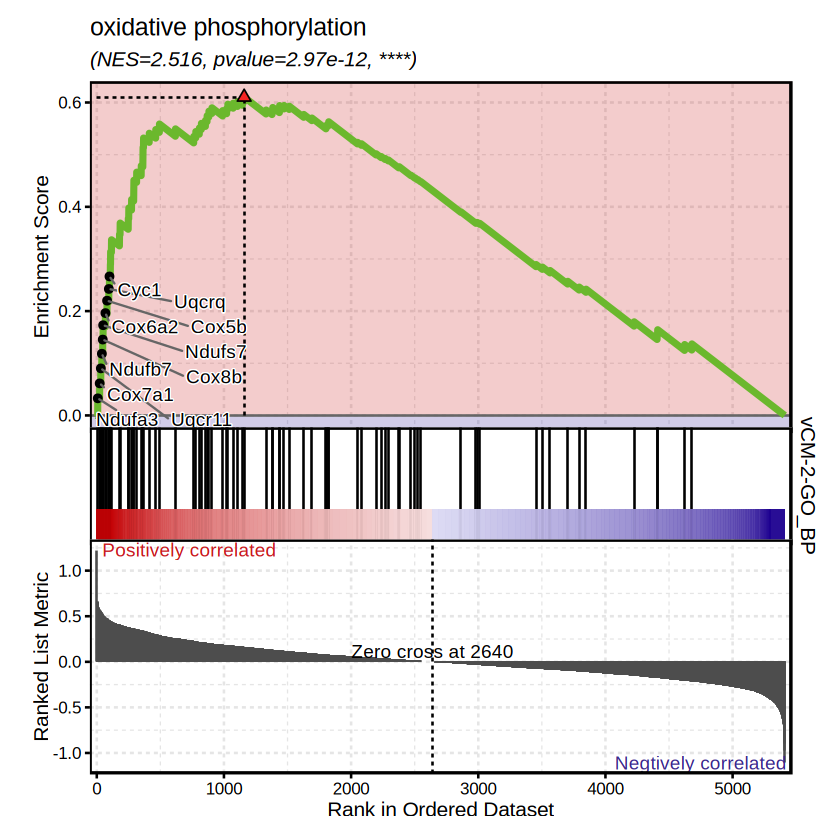

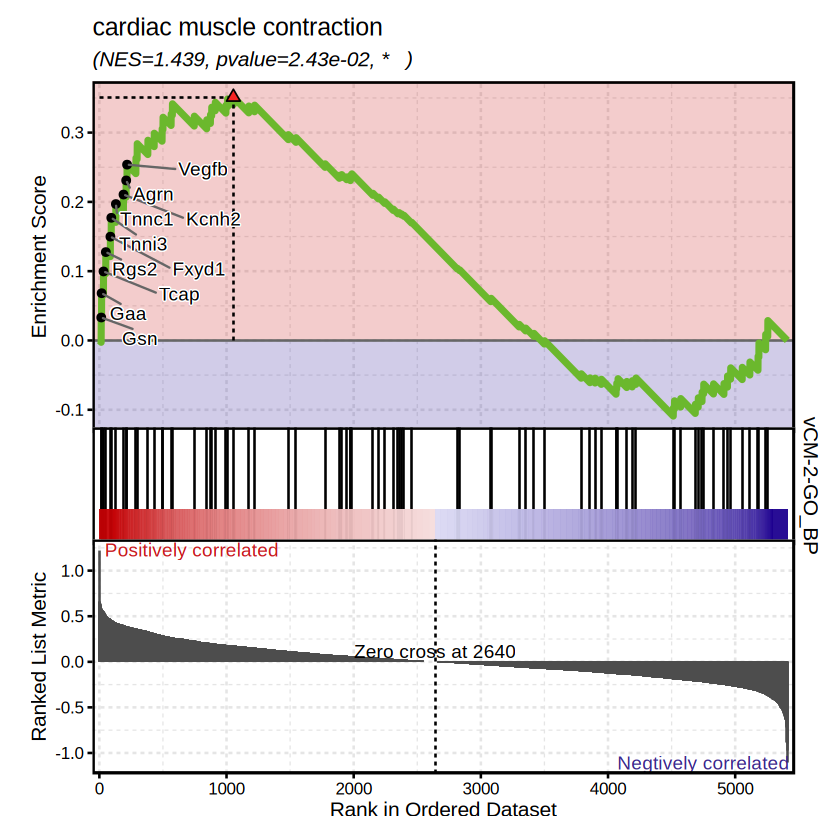

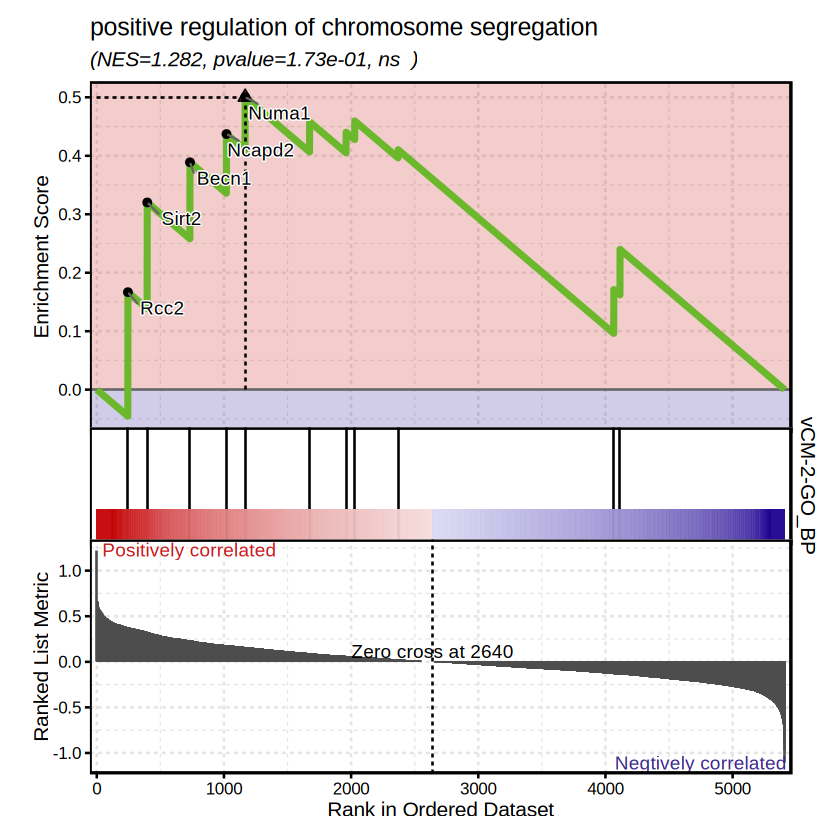

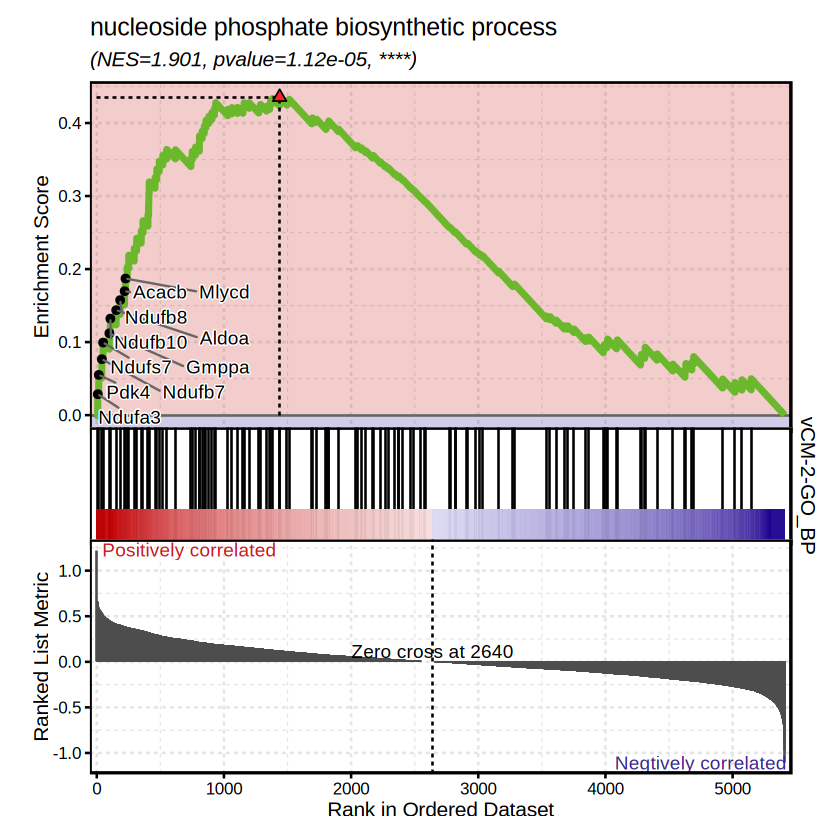

In [8]:
# GO:0006119 Oxidative phosphorylation
# GO:0060048 Cardiac muscle
# GO:0051984 Positive regulation of chromosome segregation
# GO:1901293 Nucleoside phosphate biosynthetic process
p1 <- GSEAPlot(srt = vCM, group.by = "subtype",
 group_use = "vCM-2",
 id_use = "GO:0006119",pvalueCutoff=0.05,
 padjustCutoff = NULL)
ggsave(p1,filename = "plot/figure2/fig2d_vCM_Oxidative_phosphorylation.pdf",width =4 ,height = 4)
p2 <- GSEAPlot(srt = vCM, group.by = "subtype", 
 group_use = "vCM-2",
 id_use = "GO:0060048",pvalueCutoff=0.05,
 padjustCutoff = NULL)
ggsave(p2,filename = "plot/figure2/fig2d_vCM_Cardiac_muscle.pdf",width =4 ,height = 4)
p3 <- GSEAPlot(srt = vCM, group.by = "subtype", 
 group_use = "vCM-2",
 id_use = "GO:0051984",pvalueCutoff=0.05,
 padjustCutoff = NULL)
ggsave(p3,filename = "plot/figure2/fig2d_vCM_chromosome_segregation.pdf",width =4 ,height = 4)
p4 <- GSEAPlot(srt = vCM, group.by = "subtype", 
 group_use = "vCM-2",
 id_use = "GO:1901293",pvalueCutoff=0.05,
 padjustCutoff = NULL)
ggsave(p4,filename = "plot/figure2/fig2d_vCM_Nucleoside_phosphate_biosynthetic.pdf",width =4 ,height = 4)
p1
p2
p3
p4


In [23]:
# fig2e
library(dplyr)
library(patchwork)
library(clusterProfiler)
samplegroup <- c("NP", "EP", "MP", "LP", "PP")
obj <- subset(vCM, subtype %in% "vCM-2")
# obj
obj <- RunDEtest(
 srt = obj, group.by = "group",
 fc.threshold = 1, only.pos = FALSE, min.pct = 0.1,
 group1 = "NP"
)
DEGs_group <- obj@tools$DEtest_custom$AllMarkers_wilcox
for (j in 2:5) {
 obj <- RunDEtest(
 srt = obj, group.by = "group",
 fc.threshold = 1, only.pos = FALSE, min.pct = 0.1,
 group1 = samplegroup[j], group2 = "NP"
 )
 DEGs_group <- rbind(DEGs_group, obj@tools$DEtest_custom$AllMarkers_wilcox)
}
allmarker <- DEGs_group %>%
 filter(p_val_adj < 0.05) %>%
 filter(pct.1 > 0.1) %>%
 filter(avg_log2FC > log2(1.5))
df_sig <- subset(allmarker)
group <- data.frame(
 gene = df_sig$gene,
 group = df_sig$group1
)
Gene_ID <- bitr(group$gene,
 fromType = "SYMBOL",
 toType = "ENTREZID",
 OrgDb = "org.Mm.eg.db"
)
data <- merge(Gene_ID, group, by.x = "SYMBOL", by.y = "gene")
levels(data$group) <- c("NP", "EP", "MP", "LP", "PP")
data_GO <- compareCluster(
 ENTREZID ~ group,
 data = data,
 fun = "enrichGO",
 OrgDb = "org.Mm.eg.db",
 ont = "BP",
 pAdjustMethod = "BH",
 pvalueCutoff = 0.05,
 qvalueCutoff = 0.05
)
res <- data_GO@compareClusterResult
for (i in 1:dim(res)[1]) {
 arr <- unlist(strsplit(as.character(res[i, "geneID"]), split = "/"))
 gene_names <- paste(unique(data$SYMBOL[data$ENTREZID %in% arr]), collapse = "/")
 res[i, "geneID"] <- gene_names
}

ℹ [2026-04-27 22:33:25] Data type is log-normalized

ℹ [2026-04-27 22:33:25] Start differential expression test

ℹ [2026-04-27 22:33:25] Find all markers(wilcox) for custom cell groups...

✔ [2026-04-27 22:33:28] Differential expression test completed

ℹ [2026-04-27 22:33:30] Data type is log-normalized

ℹ [2026-04-27 22:33:30] Start differential expression test

ℹ [2026-04-27 22:33:30] Find all markers(wilcox) for custom cell groups...

✔ [2026-04-27 22:33:31] Differential expression test completed

ℹ [2026-04-27 22:33:33] Data type is log-normalized

ℹ [2026-04-27 22:33:33] Start differential expression test

ℹ [2026-04-27 22:33:33] Find all markers(wilcox) for custom cell groups...

✔ [2026-04-27 22:33:35] Differential expression test completed

ℹ [2026-04-27 22:33:37] Data type is log-normalized

ℹ [2026-04-27 22:33:37] Start differential expression test

ℹ [2026-04-27 22:33:37] Find all markers(wilcox) for custom cell groups...

✔ [2026-04-27 22:33:38] Differential expression test

In [24]:
writexl::write_xlsx(res, "plot/figure2/fig2e_vCM2_group_GO.xlsx")


NP EP MP LP PP 
 3  3  3  3  3 

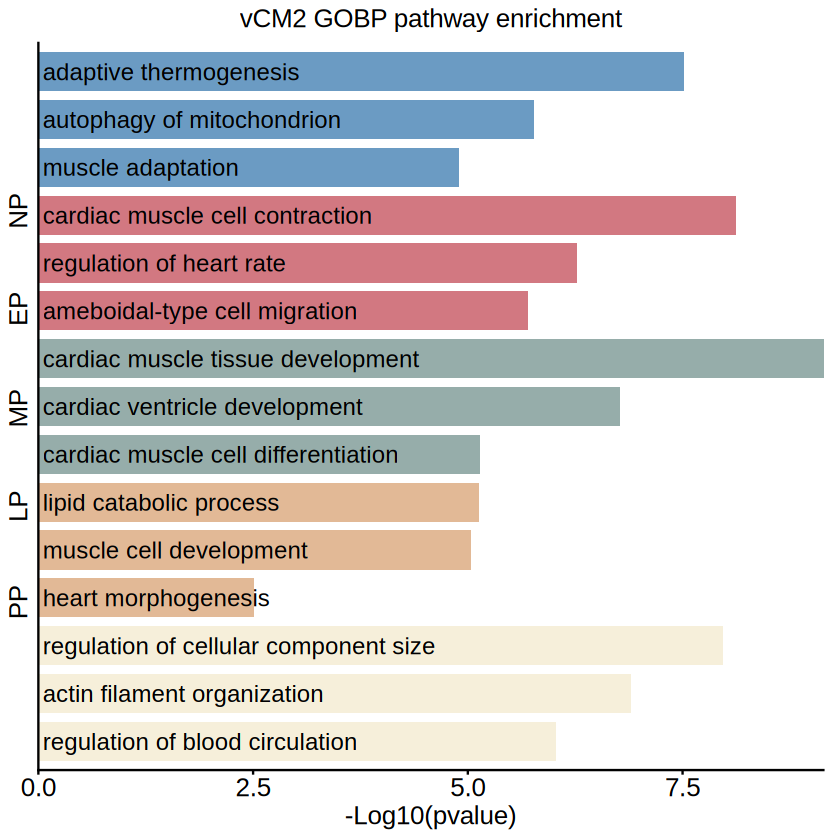

In [37]:
# plot
enrich <- subset(res, Description %in% c(
 "adaptive thermogenesis",
 "autophagy of mitochondrion",
 "muscle adaptation"
) & group %in% "NP")
enrich <- rbind(enrich, subset(res, Description %in% c(
 "cardiac muscle cell contraction",
 "regulation of heart rate",
 "ameboidal-type cell migration"
) & group %in% "EP"))
enrich <- rbind(enrich, subset(res, Description %in% c(
 "cardiac muscle tissue development",
 "cardiac muscle cell differentiation",
 "cardiac ventricle development"
) & group %in% "MP"))
enrich <- rbind(enrich, subset(res, Description %in% c(
 "lipid catabolic process",
 "heart morphogenesis",
 "muscle cell development"
) & group %in% "LP"))
enrich <- rbind(enrich, subset(res, Description %in% c(
 "regulation of blood circulation",
 "regulation of cellular component size",
 "actin filament organization"
) & group %in% "PP"))
colnames(enrich) <- gsub("Groups", "Cluster", colnames(enrich))
dt <- enrich
dt$order <- gsub("NP", "1", dt$Cluster)
dt$order <- gsub("EP", "2", dt$order)
dt$order <- gsub("MP", "3", dt$order)
dt$order <- gsub("LP", "4", dt$order)
dt$order <- gsub("PP", "5", dt$order)
dt <- dt[order(dt$pvalue), ]
dt <- dt[order(dt$order, decreasing = F), ]
table(dt$Cluster)
cols <- c("#4682B4", "#C65762", "#7C9895", "#DAA87C", "#F4EBD0")
pal <- colorRampPalette(cols)
# plot
dt$color <- factor(c(
 rep(pal(5)[3], each = 3),
 rep(pal(5)[2], each = 3),
 rep(pal(5)[1], each = 3),
 rep(pal(5)[4], each = 3),
 rep(pal(5)[5], each = 3)
), levels = pal(5))
dt$Description <- factor(dt$Description, levels = dt$Description)
dt$geneID <- paste(substr(dt$geneID, start = 1, stop = 40), "...", sep = "")
mytheme <- theme(
 axis.title = element_text(size = 15),
 axis.text = element_text(size = 15),
 axis.text.y = element_blank(), # remove y-axis pathway labels in the custom theme:
 axis.ticks.length.y = unit(0, "cm"),
 plot.title = element_text(size = 15, hjust = 0.5),
 legend.title = element_text(size = 13),
 legend.text = element_text(size = 11),
 plot.margin = margin(t = 5.5, r = 10, l = 5.5, b = 5.5)
)
p <- ggplot(data = dt, aes(
 x = -log10(pvalue),
 y = rev(Description),
 fill = Cluster
)) +
 scale_fill_manual(values = pal(5)) +
 geom_bar(stat = "identity", width = 0.8, alpha = 0.8) +
 scale_x_continuous(expand = c(0, 0)) + # align bar bottoms flush with the y-axis
 labs(
 x = "-Log10(pvalue)", y = " PP LP MP EP NP ",
 title = "vCM2 GOBP pathway enrichment"
 ) +
 # x = 0.61 numeric vector controlling the start position of text labels
 geom_text(
 size = 5,
 aes(x = 0.05, label = Description), hjust = 0
 ) + # hjust = 0,left-aligned
 theme_classic() +
 mytheme +
 NoLegend()
ggsave("plot/figure2/fig2e.pdf",p ,width = 5,height = 5)
p

In [11]:
#fig2f
#scDist analysis
library(dplyr)
library(scDist)
library(ggplot2)
library(ggpubr)
######run Dist#################
sim <- list(Y=vCM@assays$RNA$data %>% as.data.frame(),
 meta.data=vCM@meta.data %>% as.data.frame())
out <- scDist(normalized_counts = sim$Y,
 meta.data = sim$meta.data,
 d = 20, # PCA
 fixed.effects = "group", #stim
 random.effects = c('orig.ident'), #batch/sample
 clusters="subtype" #
)

Registered S3 method overwritten by 'car':
  method           from
  na.action.merMod lme4

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 7.8 GiB”
`normalized_counts` is not a matrix, converting now.



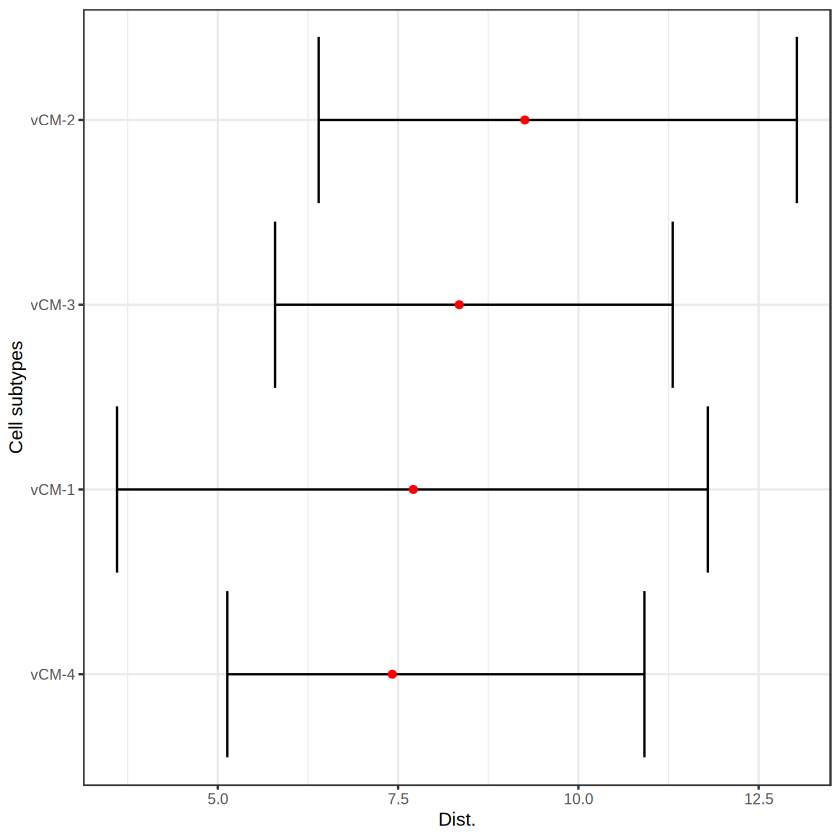

In [12]:
#plot scDist
p <- DistPlot(out)+theme_bw()+xlab(label = 'Cell subtypes')
p
ggsave("plot/figure2/fig2f_scDist.pdf", p, width = 3, height = 2.5 )

In [9]:
# fig2g
library(miloR)
library(SingleCellExperiment)
library(scater)
library(dplyr)
library(patchwork)
DefaultAssay(vCM) <- "RNA"
obj <- vCM
obj@assays <- obj@assays[1]
traj_milo_sce <- as.SingleCellExperiment(obj)
traj_milo <- Milo(traj_milo_sce)
traj_milo <- buildGraph(traj_milo)
traj_milo <- makeNhoods(traj_milo, prop = 0.1, k = 21, d = 30, refined = TRUE)
traj_milo <- countCells(traj_milo,
 meta.data = data.frame(colData(traj_milo)),
 sample = "orig.ident"
)
traj_milo@colData$preg <- ifelse(traj_milo@colData$group %in% c("NP", "PP"),
 "Non-Preg.",
 "Preg."
)
traj_design <- data.frame(colData(traj_milo))[, c("orig.ident", "preg")]
traj_design <- distinct(traj_design)
rownames(traj_design) <- c(1:15)
traj_milo <- calcNhoodDistance(traj_milo, d = 30)
row.names(traj_design) <- traj_design$orig.ident
da_results <- testNhoods(traj_milo, design = ~preg, design.df = traj_design)
da_results %>%
 arrange(-SpatialFDR) %>%
 head()
traj_milo <- buildNhoodGraph(traj_milo)

Loading required package: edgeR

Loading required package: limma



Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘matrixStats’


The following object is masked from ‘package:dplyr’:

    count



Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQRDiffs, rowIQRs, rowLogSumExps,
    rowMadDiffs, 

,logFC,logCPM,F,PValue,FDR,Nhood,SpatialFDR
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1479,0.01013580,8.998584,4.070713e-05,0.9949094,0.9949094,1479,0.9949094
1321,-0.03548002,9.503416,4.139436e-04,0.9837678,0.9841212,1321,0.9841149
1947,0.04020393,9.278287,5.856110e-04,0.9806937,0.9813985,1947,0.9814203
368,0.04991268,9.000782,8.069009e-04,0.9773385,0.9785389,368,0.9785903
2485,-0.04487133,8.956914,7.965089e-04,0.9774849,0.9785389,2485,0.9785903
2739,0.05405181,9.976045,8.489177e-04,0.9767561,0.9785129,2739,0.9784344


Adding nhood effect sizes to neighbourhood graph attributes



Scale for size is already present.
Adding another scale for size, which will replace the existing scale.


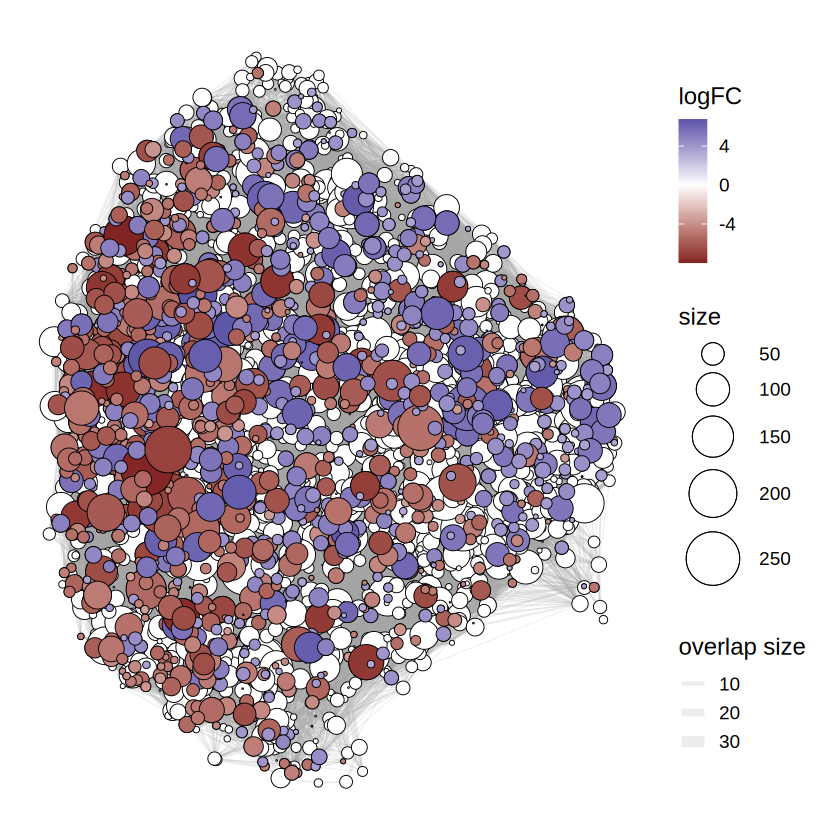

In [10]:
p <- plotNhoodGraphDA(traj_milo, da_results, alpha = 0.05) +
 scale_size(
 range = c(0, 15)
 ) +
 plot_layout(guides = "collect")
p
ggsave("plot/figure2/fig2g_MiloR.pdf", p, width = 6, height = 6)

ℹ [2026-05-07 23:46:25] Data type is raw counts

ℹ [2026-05-07 23:46:25] Start differential expression test

ℹ [2026-05-07 23:46:25] Find all markers(wilcox) for custom cell groups...

✔ [2026-05-07 23:46:29] Differential expression test completed

ℹ [2026-05-07 23:46:45] Data type is raw counts

ℹ [2026-05-07 23:46:45] Start differential expression test

ℹ [2026-05-07 23:46:45] Find all markers(wilcox) for custom cell groups...

✔ [2026-05-07 23:46:50] Differential expression test completed

ℹ [2026-05-07 23:47:04] Data type is raw counts

ℹ [2026-05-07 23:47:04] Start differential expression test

ℹ [2026-05-07 23:47:04] Find all markers(wilcox) for custom cell groups...

✔ [2026-05-07 23:47:09] Differential expression test completed

ℹ [2026-05-07 23:47:24] Data type is raw counts

ℹ [2026-05-07 23:47:24] Start differential expression test

ℹ [2026-05-07 23:47:24] Find all markers(wilcox) for custom cell groups...

✔ [2026-05-07 23:47:29] Differential expression test completed

`sum

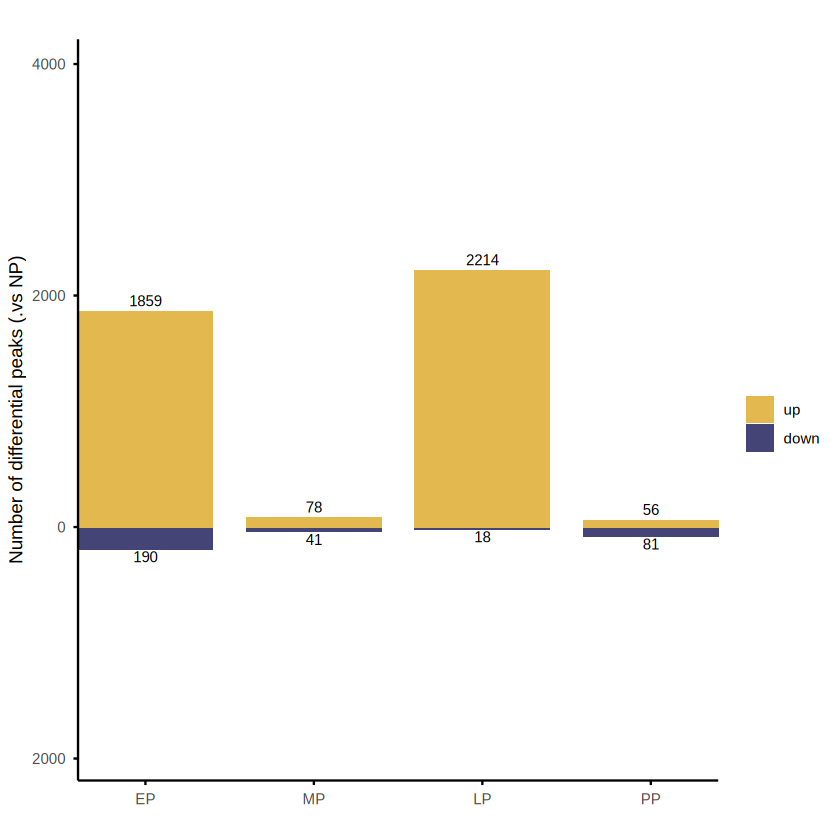

In [13]:
#fig2i
library(dplyr)
samplegroup <-c('NP','EP','MP','LP','PP')
DEGs_group <- data.frame()
 for (j in 2:5){
 vCM<- RunDEtest(srt = vCM, group.by = "group", assay = 'ATAC',layer = 'counts',
 fc.threshold = 1.5, only.pos = FALSE , min.pct = 0.1,cores = 30,
 group1 = samplegroup[j],group2 = 'NP')
 DEGs_group <- rbind(DEGs_group,vCM@tools$DEtest_custom$AllMarkers_wilcox)
 }
DEGs_group$col <- ifelse(DEGs_group$avg_log2FC>0,'up','down')
DEG_dt <- DEGs_group %>%
 group_by(group1,col) %>%
 summarise(count = n())
DEG_dt$count_adjusted <- ifelse(DEG_dt$col == "down", -DEG_dt$count, DEG_dt$count)
DEG_dt$col <- factor(DEG_dt$col, levels = c("up", "down"))
p<-ggplot(DEG_dt, aes(x = group1, y = count_adjusted, fill = col)) +
 geom_bar(stat = "identity", width = 0.8) +
 scale_fill_manual(values = rev(pal(4)[1:2])) + # colorsmust match up/down match
 geom_text(aes(label = count), # show raw value (non-negative)
 vjust = ifelse(DEG_dt$col == "up", -0.5, 1.2), # adjust text position
 color = "black", size = 3) +
 labs(
 title = "",
 x = "",
 y = "Number of differential peaks (.vs NP)",
 fill=''
 ) +
 theme_minimal() +
 theme(
 legend.position = 'right',
 panel.grid.major = element_blank(),
 panel.grid.minor = element_blank(),
 axis.line = element_line(color = "black"),
 axis.ticks = element_line(color = "black"),
 axis.text.x = element_text(angle = 0, hjust = 0.5)
 ) +
 scale_x_discrete(expand = c(0, 0)) +
 scale_y_continuous(
 expand = c(0, 0),
 limits = c(min(DEG_dt$count_adjusted ) - 2000, max(DEG_dt$count) + 2000), # symmetric range
 labels = abs # yaxis labels show absolute values
 )
p
ggsave(plot = p, filename = "fig2i.pdf",path = "plot/figure2/", width = 3.5, height = 3)

In [3]:
vCM[["activity"]] <- readRDS("data/activity.Rds")[,colnames(vCM)][["activity"]]
vCM

An object of class Seurat 
240552 features across 37984 samples within 3 assays 
Active assay: RNA (26111 features, 2000 variable features)
 3 layers present: data, counts, scale.data
 2 other assays present: ATAC, activity
 7 dimensional reductions calculated: pca, harmony, rlsi, lsi, umap, RNA.umap, ATAC.umap

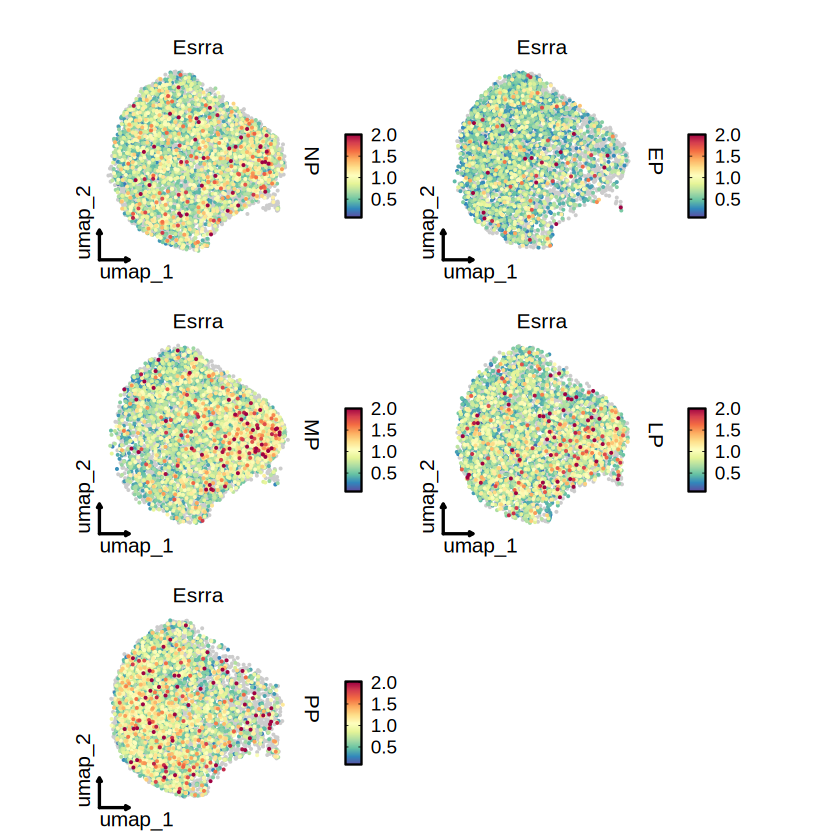

In [5]:
FeatureDimPlot(vCM,features = 'Esrra',split.by = 'group',assay= "activity",ncol = 2,theme_use = "theme_blank")

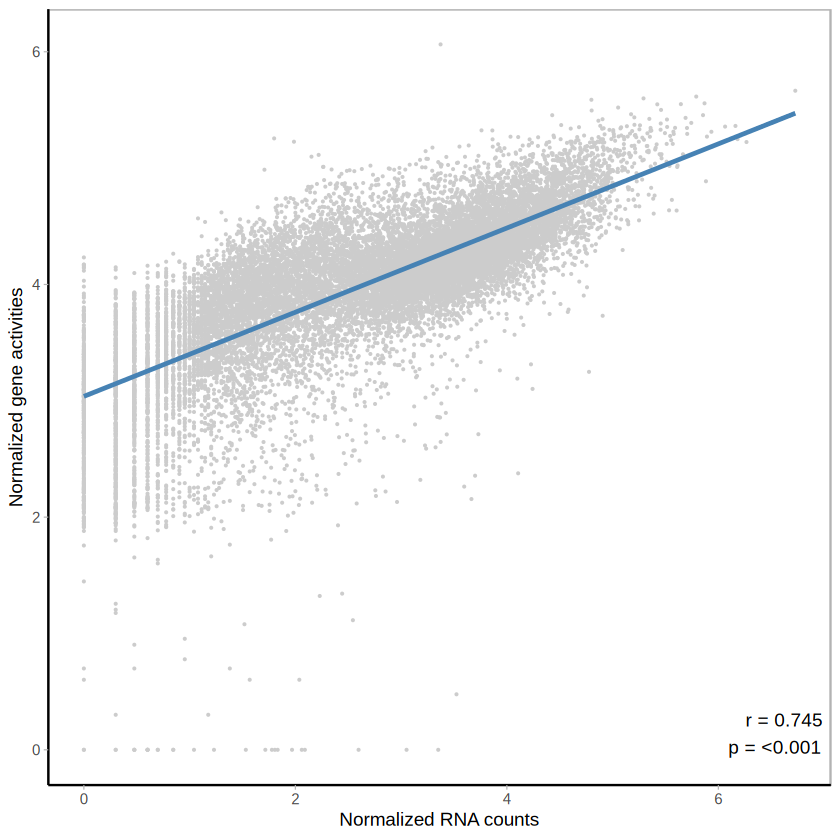

In [6]:
#fig2j
rna.dt <- AggregateExpression(vCM, assays = 'RNA',group.by = 'subtype')[[1]]
act.dt <- AggregateExpression(vCM, assays = 'activity',group.by = 'subtype')[[1]]
genes.dt <- intersect(row.names(rna.dt),row.names(act.dt))
p.dt <- data.frame(rna = rowSums(rna.dt[genes.dt,]),activities = rowSums(act.dt[genes.dt,]))
cor_value <- cor.test(log10(p.dt$rna + 1), log10(p.dt$activities + 1))
r <- round(cor_value$estimate, 3)
p_value <- scales::pvalue(cor_value$p.value)
p<-ggplot(data = p.dt, mapping = aes(x = log10(rna+1), y = log10(activities+1))) +
 geom_point(color='gray80', size=0.1) +
 geom_smooth(method = "lm", color = "#4682B4", formula = y ~ x) + # add linear regression line
 theme_light() +
 theme(
 panel.grid.major = element_blank(),
 panel.grid.minor = element_blank(),
 axis.line = element_line(color = "black"),
 legend.position = 'none'
 ) +
 xlab('Normalized RNA counts') + # fix axis label
 ylab('Normalized gene activities') +
 annotate("text", 
 x = Inf, y = 0, # place text in upper-right corner
 label = paste0("r = ", r, "\n", "p = ", p_value), 
 hjust = 1.1, vjust = 0.1, # fine-tune text position
 size = 4, color = "black")
ggsave(plot = p, filename = "fig2j.pdf",path = "plot/figure2/", width = 3, height = 3)
p

Loading required package: ggplot2




Attaching package: ‘tidygraph’


The following object is masked from ‘package:stats’:

    filter



Attaching package: ‘igraph’


The following object is masked from ‘package:tidygraph’:

    groups


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union


Loading required package: Matrix

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWei

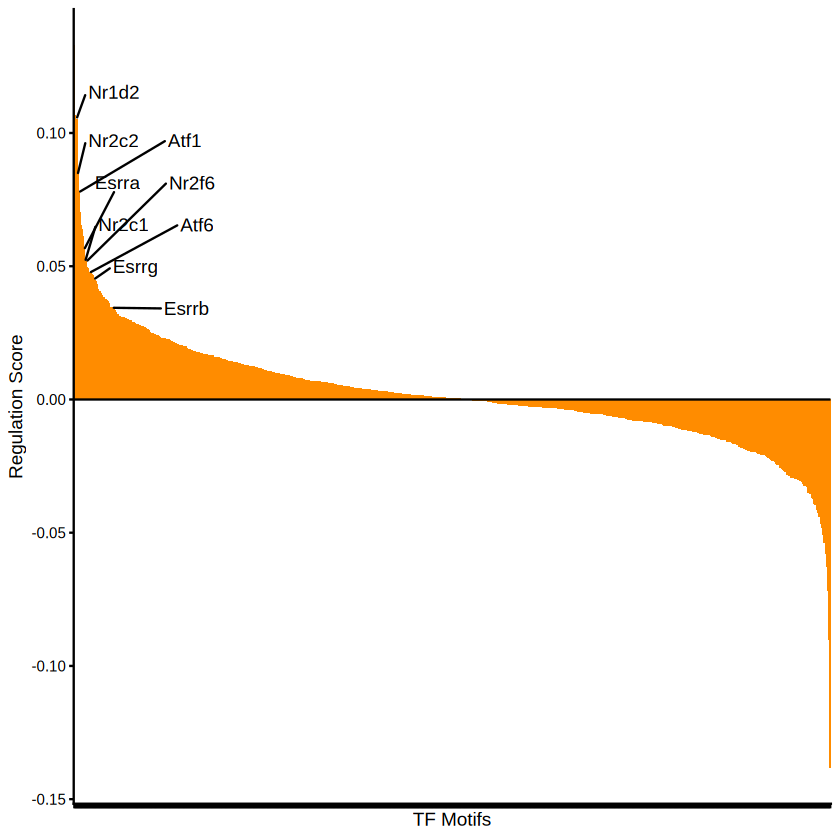

In [1]:
#fig2k
library(ggraph)
library(tidygraph)
library(igraph)
library(ggplot2)
library(FigR)
library(dplyr)
figR.d <- readRDS("data/vCM2_figR.rds")
rank.p <- rankDrivers(figR.d, rankBy = "meanScore", myLabels = c("Esrra", "Esrrg", "Esrrb","Nr1d2",
 "Nr2c2","Nr2c1","Nr2f6","Atf1","Atf6"))
rank <- rank.p@data
rank.p$data$TF <- ""
p <- rank.p + ggrepel::geom_text_repel(
 aes(label = TF),
 rank,
 max.overlaps = 200,
 box.padding = 0.6,
 min.segment.length = 0.5,
 ylim = c(0.005, NA),
 force = T
)
p
#ggsave(plot = p, filename = "fig2k.pdf",path = "plot/figure2/", width = 3.5, height =3)

In [2]:
rank.p$data

Motif,Score,TF
<fct>,<dbl>,<chr>
Tcf12,0.13293271,
Zbtb18,0.10674507,
Nr1d2,0.10524314,
Nr2c2,0.08434186,
Atf1,0.07770468,
Rreb1,0.07005583,
Hmg20a,0.06528747,
Pou5f1,0.06376121,
Nfia,0.06119437,


In [25]:
#fig2l
plot.TF <- c('Nr1d1','Nr6a1','Nr2c2','Atf2','Atf1','Esrra','Ppara')
#plot.TF <- c('Nr1d1','Esrrg','Nr2c2','Esrrb','Atf1','Esrra','Tead1')
#plot.TF <- c('Nr1d1','Nr6a1','Nr2c2','Atf2','Atf1','Esrra','Ppara')
rank <- subset(rank,Motif %in% plot.TF )
obj <- subset(vCM, subtype %in% "vCM-2")
Deg.dt <- FindMarkers(obj,group.by = 'group',ident.1 = 'LP',ident.2 = 'NP',logfc.threshold = 0,min.pct = 0)
Deg.dt$gene <- rownames(Deg.dt)
# Build the network
figR.d<- figR.d[figR.d$Score > 0.5 | figR.d$Score < -0.5, ]
tf_target_matrix <- data.frame(
 TF = figR.d$Motif,
 Target = figR.d$DORC,
 log2FC = Deg.dt[figR.d$DORC,2], # expression
 Ratio = Deg.dt[figR.d$DORC,3] # ratio
)
tf_target_matrix <- na.omit(tf_target_matrix)
# Convert the matrix into a graph object
graph <- as_tbl_graph(tf_target_matrix, directed = TRUE)
# Add node attributes: expression and ratio
specified_TFs <- rank$Motif
graph <- graph %>%
 activate(nodes) %>%
 mutate(
 Type = ifelse(name %in% tf_target_matrix$TF, "TF", "Target"),
 log2FC = ifelse(Type == "TF", 
 tf_target_matrix$log2FC[match(name, tf_target_matrix$TF)], 
 tf_target_matrix$log2FC[match(name, tf_target_matrix$Target)]),
 Ratio = ifelse(Type == "TF", 
 tf_target_matrix$Ratio[match(name, tf_target_matrix$TF)], 
 tf_target_matrix$Ratio[match(name, tf_target_matrix$Target)]),
 Size = ifelse(Type == "TF", Ratio, 0),
 Label = ifelse(name %in% specified_TFs, name, NA) # label only TFs
 )
 
# Draw the network
p2 <- ggraph(graph, layout = "circle") + 
 geom_edge_link(
 arrow = arrow(length = unit(2, 'mm')), 
 color = "gray90", 
 alpha = 0.6
 ) +
 geom_node_point(
 aes(size = Size, color = log2FC), # use adjusted Size
 alpha = 0.8
 ) +
 scale_color_gradient(low = "#FFFFFE", high = "#444576") + 
 scale_size(
 range = c(0, 10)
 ) +
 geom_text_repel(
 aes(x = x, y = y, label = Label), # show only TF labels
 size = 4, 
 color = "black",
 box.padding = 0.1, # adjust label spacing
 max.overlaps = Inf, # allow unlimited repel
 min.segment.length = 0.1 # adjust leader line length
 ) +
 theme_void() +
 labs(
 title = "MP vs NP",
 color = "log2FC",
 y = "Transcription factor − target network",
 size = 'cell ratio'
 )+
 theme(
 axis.title.y = element_text(
 angle = 90, 
 vjust = 0.5, 
 hjust = 0.5, 
 size = 12, 
 color = "black", 
 margin = margin(r = 10)
 )
 )
ggsave(plot = p2, filename = "fig2l_LPvsNP.pdf",path = "plot/figure2/", width = 4, height = 3)

Warning message:
“Removed 260 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“for 'Transcription factor − target network' in 'mbcsToSbcs': - substituted for − (U+2212)”
